# ComparisonReport Demo

Demonstrates the `skfair.comparison.ComparisonReport` class, which wraps
method-comparison visualizations into a reusable API.

| | |
|---|---|
| **Datasets** | Ricci |
| **Classifiers** | LogReg, SVC, RF, XGB |
| **Methods** | Baseline + 11 fairness algorithms |
| **Metrics** | Accuracy, Balanced Accuracy, Disparate Impact, SPD, EOD, AOD |

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline

from skfair.datasets import load_ricci
from skfair.preprocessing import (
    Massaging,
    FairSmote,
    FairOversampling,
    FAWOS,
    HeterogeneousFOS,
    FairwayRemover,
    GeometricFairnessRepair,
    LearningFairRepresentations,
    ReweighingClassifier,
    FairBalanceClassifier,
    FairMask,
)
from skfair.metrics import (
    accuracy,
    balanced_accuracy,
    disparate_impact,
    statistical_parity_difference,
    equal_opportunity_difference,
    average_odds_difference,
)
from skfair.comparison import ComparisonReport

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 2. Datasets & Classifiers

In [2]:
datasets = {
    "Ricci" : load_ricci(),
}

CLASSIFIERS = {
    "LogReg": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    "SVC":    SVC(probability=True, kernel="rbf", random_state=42),
    "RF":     RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB":    XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0),
}

for name, (X, y) in datasets.items():
    print(f"{name:15s}: {X.shape[0]:6d} samples, {X.shape[1]:3d} features")

Ricci          :    118 samples,   4 features


## 3. Method Factory & CV Runner

In [3]:

# --- Method registry ---
# Each entry: (MethodClass, kwargs_dict)
#   - "sampler/transformer" methods go before the clf in the pipeline
#   - "meta" methods wrap the clf as estimator=
#   - Baseline has no method step

sens_attr_ = "Race"

SAMPLERS = {
    "Massaging":       (Massaging,       {"sens_attr": sens_attr_, "priv_group": 1}),
    "FairSmote":       (FairSmote,       {"sens_attr": sens_attr_, "random_state": 42}),
    "FairOversampling":(FairOversampling, {"sens_attr": sens_attr_, "priv_group": 1, "random_state": 42}),
    "FAWOS":           (FAWOS,           {"sens_attr": sens_attr_, "priv_group": 1, "random_state": 42}),
    "HeterogeneousFOS":(HeterogeneousFOS, {"sens_attr": sens_attr_, "random_state": 42}),
    "FairwayRemover":  (FairwayRemover,  {"sens_attr": sens_attr_, "priv_group": 1}),
}

# These need numeric_cols from X, resolved at build time
REPAIR_METHODS = {
    "GeometricFairnessRepair": (GeometricFairnessRepair, lambda cols: {
        "sens_attr": sens_attr_, "repair_columns": cols, "lambda_param": 1.0,
    }),
    "LearningFairRepresentations": (LearningFairRepresentations, lambda cols: {
        "sens_attr": sens_attr_, "priv_group": 1, "random_state": 42,
    }),
}

META_ESTIMATORS = {
    "ReweighingClassifier":  (ReweighingClassifier,  {"sens_attr": sens_attr_}),
    "FairBalanceClassifier": (FairBalanceClassifier,  {"sens_attr": sens_attr_}),
    "FairMask":              (FairMask,              {"sens_attr": sens_attr_, "random_state": 42}),
}

METHODS = ["Baseline"] + list(SAMPLERS) + list(REPAIR_METHODS) + list(META_ESTIMATORS)


def build_pipeline(method_key, clf_name, clf, X):
    """Return an ImbPipeline for (method, clf)."""
    clf = clone(clf)

    if method_key == "Baseline":
        return ImbPipeline([("clf", clf)])

    if method_key in SAMPLERS:
        cls, kw = SAMPLERS[method_key]
        return ImbPipeline([("method", cls(**kw)), ("clf", clf)])

    if method_key in REPAIR_METHODS:
        cls, kw_fn = REPAIR_METHODS[method_key]
        numeric_cols = [c for c in X.select_dtypes(include=["number"]).columns if c != sens_attr_]
        return ImbPipeline([("method", cls(**kw_fn(numeric_cols))), ("clf", clf)])

    if method_key in META_ESTIMATORS:
        cls, kw = META_ESTIMATORS[method_key]
        return ImbPipeline([("clf", cls(estimator=clf, **kw))])

    raise ValueError(f"Unknown method: {method_key}")


def run_cv(pipeline, X, y, sens_col=sens_attr_, n_splits=5, seed=42):
    """Stratified k-fold CV; returns dict of {metric_mean, metric_std}."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    X = X.reset_index(drop=True)
    y_arr = np.asarray(y)

    fold_metrics = {
        m: [] for m in ["accuracy", "balanced_accuracy",
                        "disparate_impact", "spd", "eod", "aod"]
    }

    METRIC_FNS = {
        "accuracy": lambda yt, yp, s: accuracy(yt, yp),
        "balanced_accuracy": lambda yt, yp, s: balanced_accuracy(yt, yp),
        "disparate_impact": disparate_impact,
        "spd": statistical_parity_difference,
        "eod": equal_opportunity_difference,
        "aod": average_odds_difference,
    }

    for train_idx, test_idx in skf.split(X, y_arr):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test  = X.iloc[test_idx].reset_index(drop=True)
        y_train = y_arr[train_idx]
        y_test  = y_arr[test_idx]
        sens_test = X_test[sens_col].values

        pipe = clone(pipeline)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        for name, fn in METRIC_FNS.items():
            fold_metrics[name].append(fn(y_test, y_pred, sens_test))

    result = {}
    for m, vals in fold_metrics.items():
        result[f"{m}_mean"] = float(np.mean(vals))
        result[f"{m}_std"]  = float(np.std(vals))
    return result


print(f"{len(METHODS)} methods, {len(CLASSIFIERS)} classifiers")


12 methods, 4 classifiers


## 4. Build Results DataFrame

In [4]:
results = []

for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print("=" * 60)

    for method_key in METHODS:
        for clf_name, clf in CLASSIFIERS.items():
            label = f"{method_key:30s} | {clf_name:6s}"
            try:
                pipeline  = build_pipeline(method_key, clf_name, clf, X)
                cv_result = run_cv(pipeline, X, y)
                row = {
                    "dataset": dataset_name,
                    "method": method_key,
                    "classifier": clf_name,
                    **cv_result,
                }
                results.append(row)
                print(f"  {label}  acc={row['accuracy_mean']:.3f}  spd={row['spd_mean']:.3f}")
            except Exception as exc:
                print(f"  {label}  FAILED: {exc}")
                row = {
                    "dataset": dataset_name,
                    "method": method_key,
                    "classifier": clf_name,
                }
                for m in ["accuracy", "balanced_accuracy", "disparate_impact",
                          "spd", "eod", "aod"]:
                    row[f"{m}_mean"] = float("nan")
                    row[f"{m}_std"]  = float("nan")
                results.append(row)

results_df = pd.DataFrame(results)
print(f"\nTotal rows: {len(results_df)}")
results_df.head()


Dataset: Ricci
  Baseline                       | LogReg  acc=0.812  spd=-0.509
  Baseline                       | SVC     acc=0.914  spd=-0.369
  Baseline                       | RF      acc=0.906  spd=-0.334
  Baseline                       | XGB     acc=0.940  spd=-0.316
  Massaging                      | LogReg  acc=0.685  spd=0.004
  Massaging                      | SVC     acc=0.863  spd=-0.377
  Massaging                      | RF      acc=0.830  spd=-0.048
  Massaging                      | XGB     acc=0.813  spd=-0.011
  FairSmote                      | LogReg  acc=0.830  spd=-0.125
  FairSmote                      | SVC     acc=0.923  spd=-0.339
  FairSmote                      | RF      acc=0.881  spd=-0.311
  FairSmote                      | XGB     acc=0.889  spd=-0.288
  FairOversampling               | LogReg  acc=0.787  spd=-0.162
  FairOversampling               | SVC     acc=0.889  spd=-0.333
  FairOversampling               | RF      acc=0.906  spd=-0.293
  FairOver

,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,Ricci,Baseline,LogReg,0.811594,0.122456,0.811655,0.123102,0.289444,0.115567,-0.509213,0.116894,-0.334524,0.225827,-0.323810,0.212521
1,Ricci,Baseline,SVC,0.914493,0.039713,0.914918,0.040560,0.440101,0.131968,-0.369213,0.108299,-0.079762,0.169182,-0.121429,0.110551
2,Ricci,Baseline,RF,0.905797,0.051584,0.904429,0.051209,0.450411,0.186802,-0.334258,0.142660,-0.034524,0.320908,-0.100595,0.093972
3,Ricci,Baseline,XGB,0.940217,0.044078,0.940035,0.043477,0.509113,0.167368,-0.315754,0.137721,0.078571,0.064484,-0.039048,0.062063
4,Ricci,Massaging,LogReg,0.685145,0.092419,0.687587,0.093983,1.031284,0.290206,0.003627,0.160255,0.082381,0.277359,0.132540,0.179292


## 5. Create ComparisonReport

In [5]:
report = ComparisonReport(results_df)

print(f"Datasets:    {report.datasets}")
print(f"Methods:     {report.methods}")
print(f"Classifiers: {report.classifiers}")
print(f"Metrics:     {report.metrics}")
print(f"Performance: {report.performance_metrics}")
print(f"Fairness:    {report.fairness_metrics}")

Datasets:    ['Ricci']
Methods:     ['Baseline', 'FAWOS', 'FairBalanceClassifier', 'FairMask', 'FairOversampling', 'FairSmote', 'FairwayRemover', 'GeometricFairnessRepair', 'HeterogeneousFOS', 'LearningFairRepresentations', 'Massaging', 'ReweighingClassifier']
Classifiers: ['LogReg', 'RF', 'SVC', 'XGB']
Metrics:     ['accuracy', 'balanced_accuracy', 'disparate_impact', 'spd', 'eod', 'aod']
Performance: ['accuracy', 'balanced_accuracy']
Fairness:    ['disparate_impact', 'spd', 'eod', 'aod']


## 6. Performance Bars

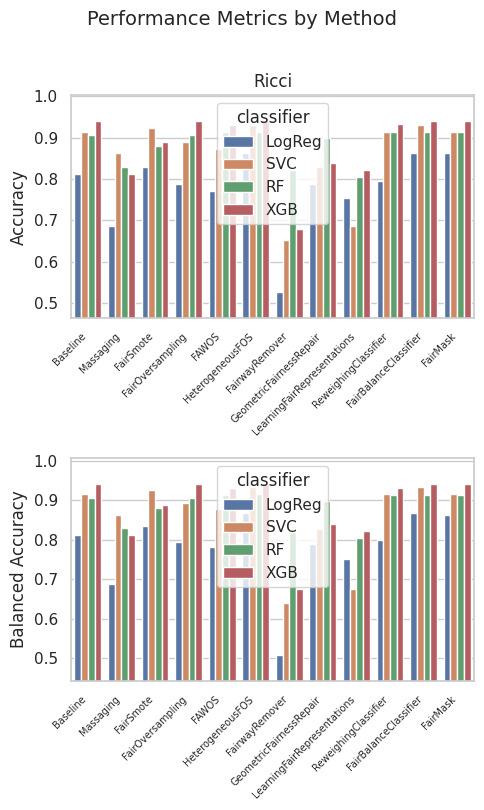

In [6]:
report.plot_performance()
plt.show()

## 7. Fairness — Averaged over Classifiers

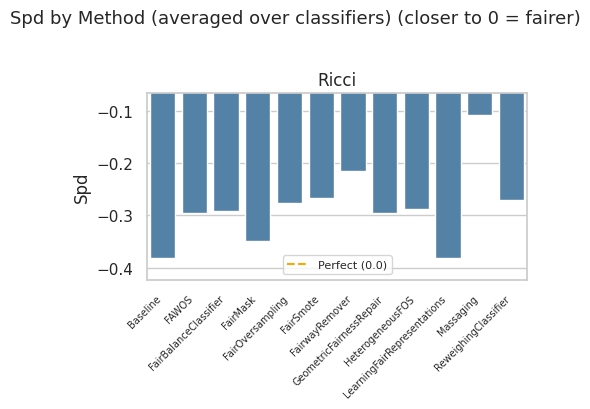

In [7]:
report.plot_fairness_averaged(metric="spd")
plt.show()

## 8. Fairness — Detailed (per classifier)

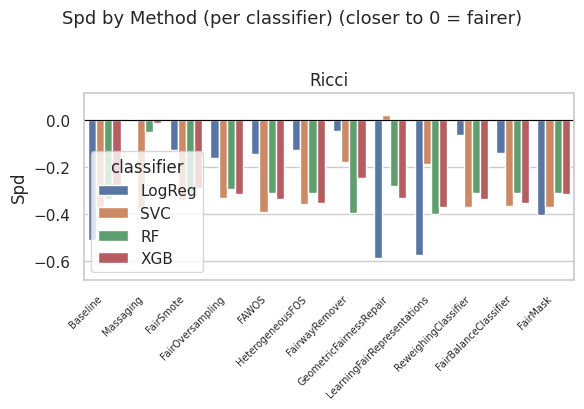

In [8]:
report.plot_fairness_detailed(metric="spd")
plt.show()

## 9. Performance vs Fairness Trade-off

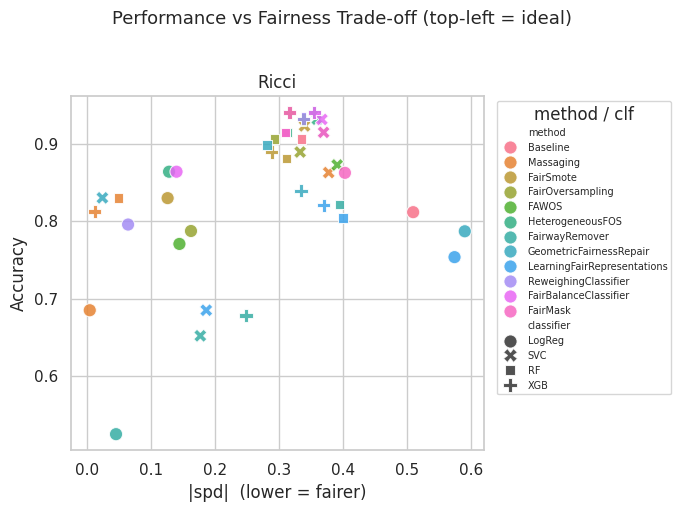

In [9]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy")
plt.show()

## 10. Summary Tables

In [10]:
tables = report.summary_tables()
for ds, tbl in tables.items():
    print(f"\n{'='*60}\n{ds}\n{'='*60}")
    display(tbl)


Ricci


,accuracy,balanced_accuracy,disparate_impact,spd,eod,aod
method,,,,,,
Baseline,0.8930,0.8928,0.4223,-0.3821,-0.0926,-0.1462
FAWOS,0.8722,0.8760,0.5799,-0.2954,0.0161,-0.0717
FairBalanceClassifier,0.9123,0.9136,0.5590,-0.2924,0.0187,-0.0448
FairMask,0.9078,0.9080,0.4697,-0.3492,-0.0176,-0.1025
FairOversampling,0.8806,0.8832,0.6018,-0.2757,0.0449,-0.0438
FairSmote,0.8806,0.8823,0.6063,-0.2661,0.0142,-0.0401
FairwayRemover,0.6694,0.6606,0.4023,-0.2158,-0.1724,-0.1471
GeometricFairnessRepair,0.8386,0.8380,0.5857,-0.2953,-0.0671,-0.0963
HeterogeneousFOS,0.9125,0.9143,0.5769,-0.2885,0.0229,-0.0404


## 11. Ranking Heatmap

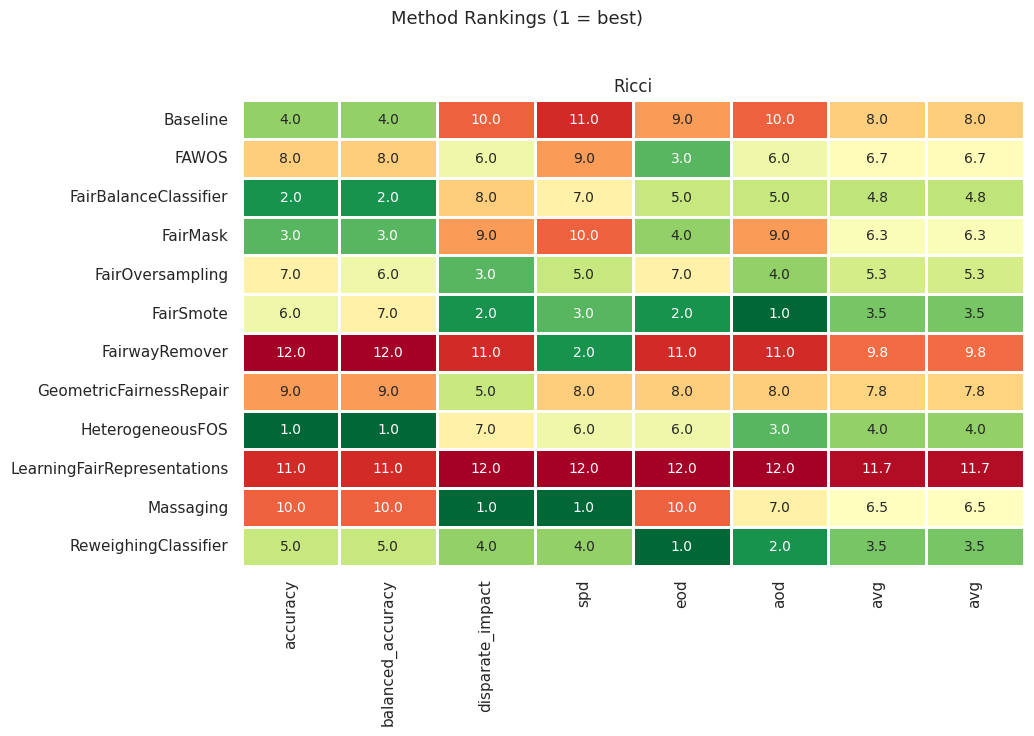

In [11]:
report.plot_ranking()
plt.show()

## 12. Full Summary (plot_all)

5 figures generated


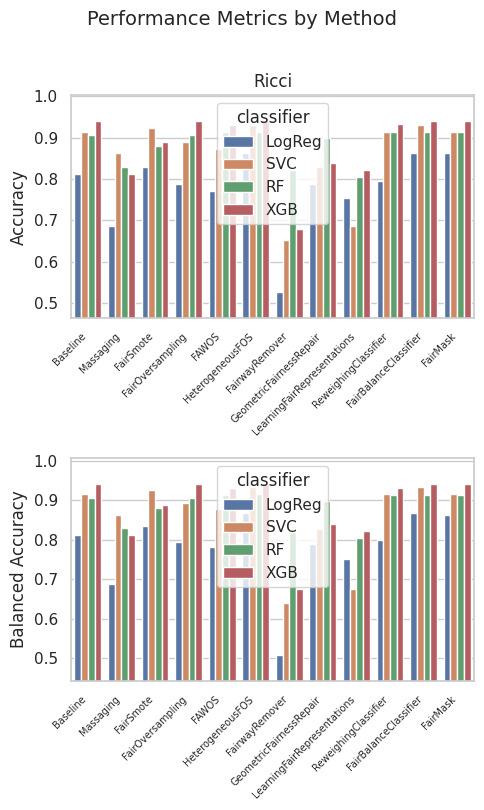

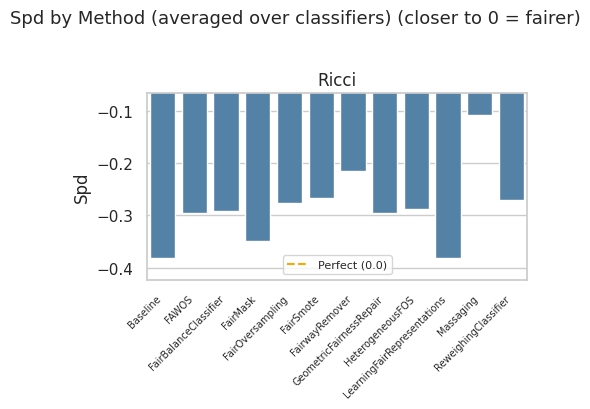

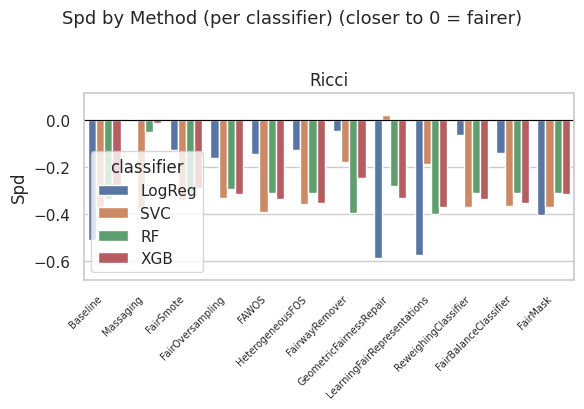

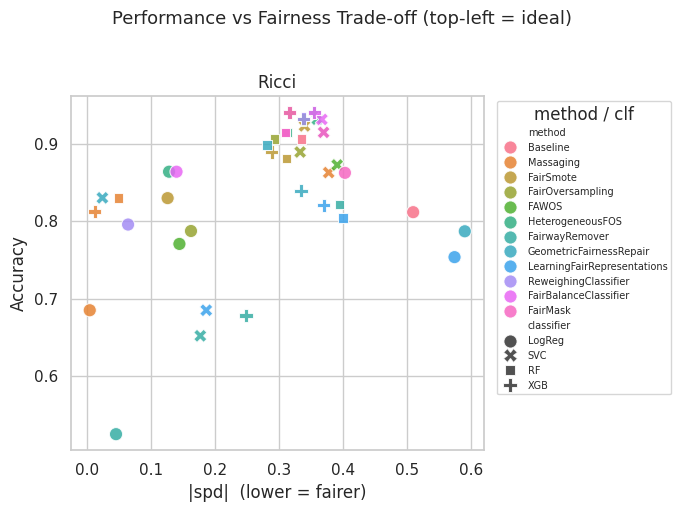

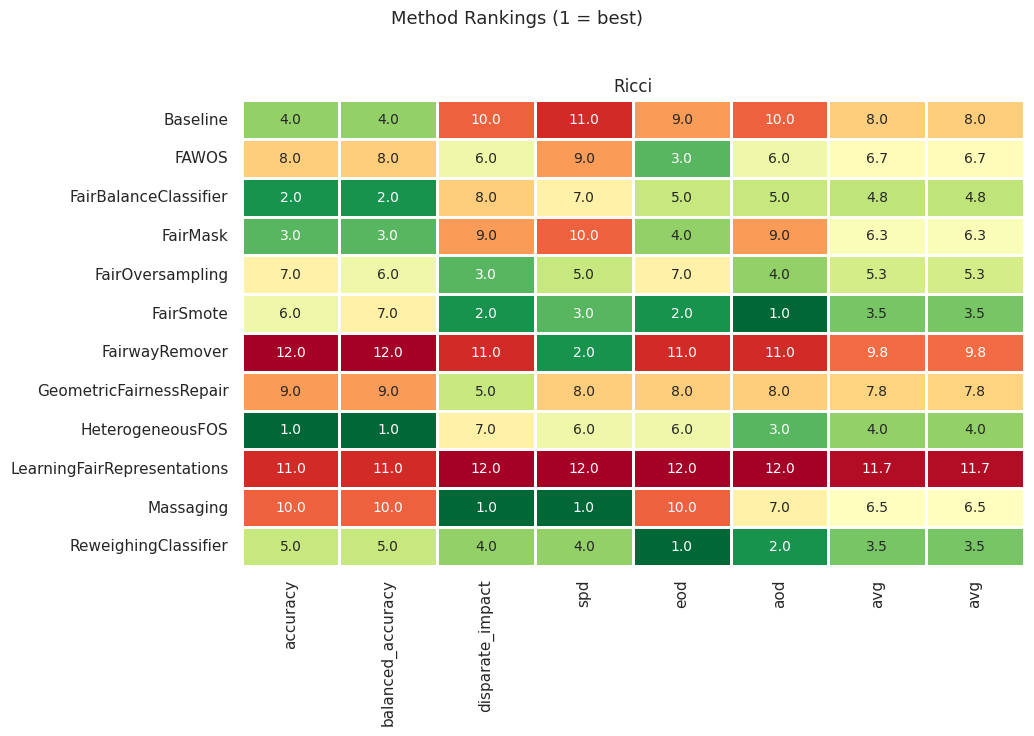

In [12]:
all_figs = report.plot_all()
print(f"{len(all_figs)} figures generated")
plt.show()